In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V = 'refined-manual-niches'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
comb.obs['condition'].value_counts()

condition
CF      892834
CTRL    172945
Name: count, dtype: int64

In [4]:
# %% Load annotations and update comb.obs
ann_path = MAIN_DIR / "data" / "sample_sheet" / "sample_sheet.tsv"
ann = pd.read_csv(ann_path, sep="\t")

# Make sure each sample appears only once in the sample sheet
assert ann["sample_name"].is_unique

# Use sample_name as lookup index
ann_idx = ann.set_index("sample_name")

# Overwrite existing metadata columns and add new ones
for col in ann_idx.columns:
    comb.obs[col] = comb.obs["sample_name"].map(ann_idx[col])


In [5]:
ann.head()

,slide_name,sample_name,condition,donor,run,modulator,age,mutation,sex
0,SLIDE01,PWCF01_1,CF,PWCF01,RUN01,NO,UNK,F508del/F508del,M
1,SLIDE01,PWCF01_2,CF,PWCF01,RUN01,NO,UNK,F508del/F508del,M
2,SLIDE02,PWCF02,CF,PWCF02,RUN02,NO,UNK,F508del/F508del,F
3,SLIDE02,PWCF03,CF,PWCF03,RUN02,NO,UNK,F508del/F508del,M
4,SLIDE02,PWCF04,CF_ETI,PWCF04,RUN02,ETI,UNK,F508del/F508del,M


In [6]:
comb.obs['condition'].unique()

array(['CTRL', 'CF', 'CF_ETI'], dtype=object)

... storing 'slide_name' as categorical
... storing 'condition' as categorical
... storing 'donor' as categorical
... storing 'run' as categorical
... storing 'modulator' as categorical
... storing 'age' as categorical
... storing 'mutation' as categorical
... storing 'sex' as categorical


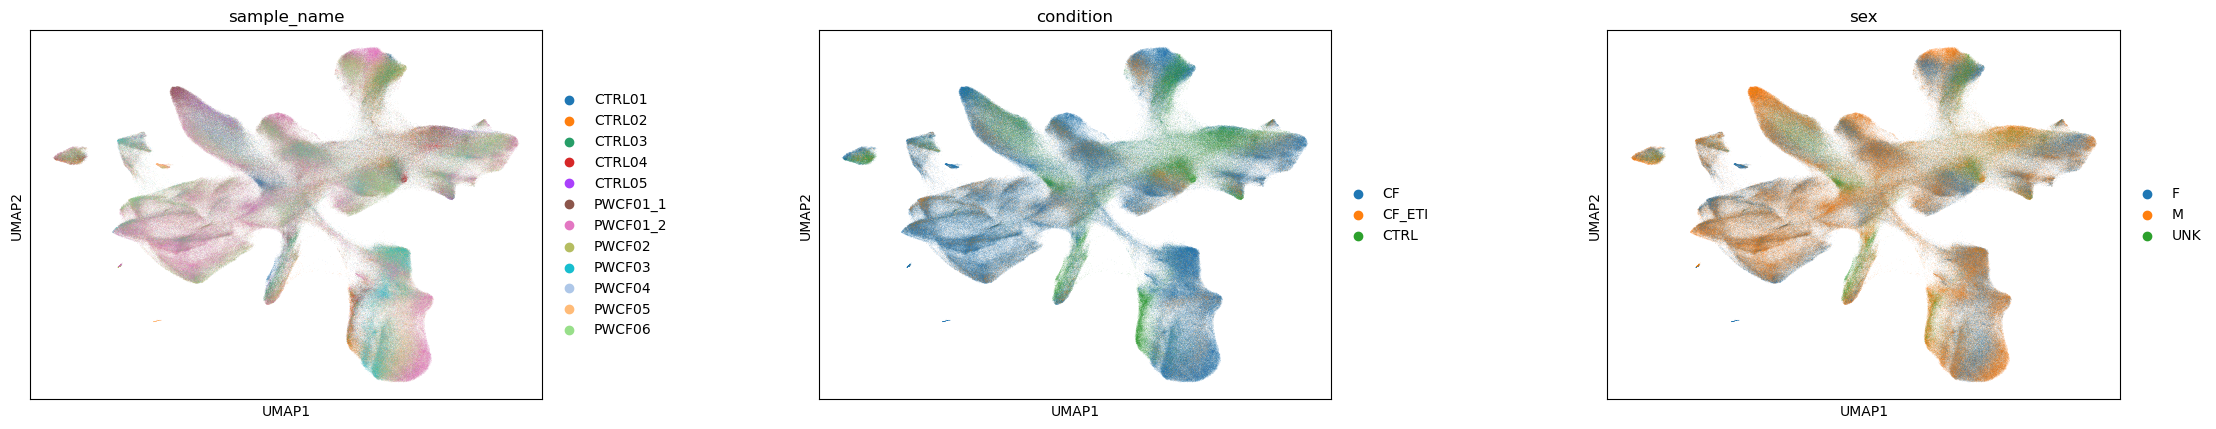

In [7]:
sc.pl.umap(comb, color=['sample_name', 'condition','sex'], wspace=0.4)

## Save updated annotations

In [8]:
comb.write_h5ad(COMB_PATH)

In [9]:
comb.obs['niche_name'].value_counts()

niche_name
interstitium         338593
alveolar             319341
airway_epithelium    238395
neutrophil_rich       84744
TLS                   84706
Name: count, dtype: int64

In [14]:
len(comb.obs['ann_lvl_3_refined'].unique().tolist())

24